# 🧠 Objective

Now that you've prepared a gold-layer dataset for predicting customer churn, your next task is to explore how different machine learning models make predictions.

This assignment focuses on understanding model behavior, not on measuring accuracy. You’ll select two models, train them on your gold dataset, and compare how they approach decision-making.

---

## 📂 Load Your Gold Dataset

- Load your `customer_churn_gold.csv` dataset  
- Check for nulls, data types, and shapes  
- Split into features (`X`) and target (`y = Churn`)  

✍️ **Write**: One sentence confirming your dataset is loaded and looks correct.

---

## 🧪 Choose Two ML Models from This Module

Pick any two models suitable for classification tasks covered in this module:

- Logistic Regression  
- Decision Tree  
- Naive Bayes  
- K-nearest Neighbors (KNN)  

Your goal is to compare **how these models work**, not which one is more accurate.

---

## 🤖 Train Both Models

- Use the **full dataset** (no train/test split needed yet)  
- Use `sklearn` implementations for simplicity:
  - `LogisticRegression`
  - `DecisionTreeClassifier`
  - `GaussianNB`
  - `KNeighborsClassifier`  

- Print the model structure or logic, such as:
  - Coefficients (for logistic regression)
  - Tree splits (for decision trees)
  - Neighbors used (for KNN)
  - Probabilities (for Naive Bayes)

✍️ **Write for each model** (2–4 sentences):

- What inputs it uses  
- How it makes predictions  
- What outputs it gives  
- One observation about its logic or assumptions  

---

## 🔍 Compare the Two Models

✍️ **Write a short paragraph (~150 words)** comparing the two models based on:

- How they represent relationships between input and output  
- Whether their decisions are interpretable  
- What kind of patterns they seem to learn (e.g., linear, thresholds, proximity)  
- Any surprises you found  

You don’t need to evaluate performance — just explain what you learned about how these models “think”.

---

## 🎨 Optional: Visualize a Prediction

Pick one sample row from your dataset. For both models:

- Show the prediction  
- Explain which features contributed to the result  
- If possible, visualize or describe the internal decision path (e.g., tree split, neighbor influence)  

---


### Let's get started

## 📂 Load Your Gold Dataset

- Load your `customer_churn_gold.csv` dataset
- Your dataset is stored at `additional_files/customer_churn_dataset-training-master.csv`
- Check for nulls, data types, and shapes  
- Split into features (`X`) and target (`y = Churn`)
- Store your results in variable `X` and `y`

In [2]:
import pandas as pd
import numpy as np 

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [3]:
# YOUR CODE HERE
df = pd.read_csv('additional_files/customer_churn_gold.csv')
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,Churn_encoded,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,0,5375.0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,...,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.0,0.083333,0,0.0
1,1,3962.0,1.0,0,0.0,0.0,34,1.0,0.0,0.0,...,56.95,1889.50,-0.172165,0.066327,-0.259629,0.0,1.0,2.833333,1,0.0
2,2,2564.0,1.0,0,0.0,0.0,2,1.0,0.0,0.0,...,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,1.0,0.166667,0,0.0
3,3,5535.0,1.0,0,0.0,0.0,45,0.0,1.0,0.0,...,42.30,1840.75,-0.193672,0.514251,-0.746535,0.0,2.0,3.750000,1,0.0
4,4,6511.0,0.0,0,0.0,0.0,2,1.0,0.0,1.0,...,70.70,151.65,-0.938874,-1.236724,0.197365,1.0,0.0,0.166667,0,0.0


In [4]:
df.drop(df.columns[0], inplace = True, axis =1)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,Churn_encoded,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,5375.0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,...,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.0,0.083333,0,0.0
1,3962.0,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,...,56.95,1889.50,-0.172165,0.066327,-0.259629,0.0,1.0,2.833333,1,0.0
2,2564.0,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,...,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,1.0,0.166667,0,0.0
3,5535.0,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,...,42.30,1840.75,-0.193672,0.514251,-0.746535,0.0,2.0,3.750000,1,0.0
4,6511.0,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,...,70.70,151.65,-0.938874,-1.236724,0.197365,1.0,0.0,0.166667,0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customerID             7043 non-null   float64
 1   gender                 7043 non-null   float64
 2   SeniorCitizen          7043 non-null   int64  
 3   Partner                7043 non-null   float64
 4   Dependents             7043 non-null   float64
 5   tenure                 7043 non-null   int64  
 6   PhoneService           7043 non-null   float64
 7   MultipleLines          7043 non-null   float64
 8   InternetService        7043 non-null   float64
 9   OnlineSecurity         7043 non-null   float64
 10  OnlineBackup           7043 non-null   float64
 11  DeviceProtection       7043 non-null   float64
 12  TechSupport            7043 non-null   float64
 13  StreamingTV            7043 non-null   float64
 14  StreamingMovies        7043 non-null   float64
 15  Cont

In [6]:
X = df[ df.columns[df.columns != 'Churn_encoded' ] ]
X.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,5375.0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,...,1.0,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.083333,0,0.0
1,3962.0,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,...,0.0,56.95,1889.50,-0.172165,0.066327,-0.259629,1.0,2.833333,1,0.0
2,2564.0,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,...,1.0,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,0.166667,0,0.0
3,5535.0,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,...,0.0,42.30,1840.75,-0.193672,0.514251,-0.746535,2.0,3.750000,1,0.0
4,6511.0,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,...,1.0,70.70,151.65,-0.938874,-1.236724,0.197365,0.0,0.166667,0,0.0


In [7]:
y = df['Churn_encoded']
y.astype('int64')

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn_encoded, Length: 7043, dtype: int64

Data successfully split into X(features) and y(Target)

---

## 🧪 Choose Two ML Models from This Module

Pick any two models suitable for classification tasks covered in this module:

- Logistic Regression  
- Decision Tree  
- Naive Bayes  
- K-nearest Neighbors (KNN)  

Your goal is to compare **how these models work**, not which one is more accurate.


In [8]:
# Example imports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# You can pick any 2 you want

### Data Preparation

Clean the data if need be. Make your data suitable for consumption by the model

In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

---

## 🤖 Train Both Models

- Use the **full dataset** (no train/test split needed yet)  
- Use `sklearn` implementations for simplicity:
  - `LogisticRegression`
  - `DecisionTreeClassifier`
  - `GaussianNB`
  - `KNeighborsClassifier`  

### Once the model is trained.
- If you use `LogisticRegression`, store the learned coefficients in a variable named `logistic_coefficients`. Like this
 
```
logistic_coefficients = model.coef_
```

- If you use `DecisionTreeClassifier`, store the tree structure (as text) in a variable named `tree_structure` using export_text. Like this 
```
from sklearn.tree import export_text
tree_structure = export_text(model, max_depth=3)
```

- If you use `GaussianNB`, store the class prior probabilities in a variable named `nb_probabilities`. Like this
```
nb_probabilities = model.class_prior_
```


- If you use `KNeighborsClassifier`, store the distances and indices of the nearest neighbors for the first 5 points in a variable named `knn_neighbors_info` as a tuple (distances, indices). Like this

```
knn_neighbors_info = model.kneighbors(X[:5])
```


<!-- - Print the model structure or logic, such as:
  - Coefficients (for logistic regression)
  - Tree splits (for decision trees)
  - Neighbors used (for KNN)
  - Probabilities (for Naive Bayes) -->

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [10]:
# Training a LogisticRegression model:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X,y)

LogisticRegression(max_iter=1000)

In [11]:
logistic_coefficients = model1.coef_
logistic_coefficients

array([[-2.22187717e-05, -3.24635649e-02,  2.75536086e-01,
        -9.73340618e-03, -1.98972355e-01, -5.07280747e-02,
        -3.73648070e-01,  1.10906621e-01,  1.17429491e-01,
        -2.71258336e-01, -1.19666838e-01, -5.16981593e-02,
        -2.62923990e-01, -5.80744589e-04,  9.28859388e-03,
        -7.37808458e-01,  4.14788736e-01,  1.39422023e-02,
         2.35260187e-04,  5.23485532e-02,  6.65416863e-02,
         1.12491504e-01, -1.72471058e-01, -4.22733956e-03,
        -2.29155367e-01,  8.70784930e-03]])

In [12]:
#Training a KNN model
model2 = KNeighborsClassifier(n_neighbors = 3)
model2.fit(X,y)

KNeighborsClassifier(n_neighbors=3)

In [13]:
knn_neighbors_info = model2.kneighbors(X[:5])

In [14]:
knn_neighbors_info

(array([[ 0.        , 21.38450866, 23.56913167],
        [ 0.        , 45.47428155, 46.28728655],
        [ 0.        , 37.11731442, 38.75254968],
        [ 0.        , 39.10739887, 71.28647396],
        [ 0.        , 30.30068397, 44.29896647]]),
 array([[   0, 6449, 3332],
        [   1, 4548, 6802],
        [   2, 3857, 3043],
        [   3, 5238, 4878],
        [   4, 1341, 1941]]))

In [18]:
model2.kneighbors(X[6447:6450])

(array([[1.22070312e-04, 6.16360427e+01, 7.24338826e+01],
        [0.00000000e+00, 3.81194927e+01, 9.51410957e+01],
        [0.00000000e+00, 1.60318437e+01, 2.13845087e+01]]),
 array([[6447, 3428, 4264],
        [6448,  487,  778],
        [6449, 1252,    0]]))

---

✍️ **Write for each model** (2–4 sentences):

- What inputs it uses  
- How it makes predictions  
- What outputs it gives  
- One observation about its logic or assumptions  


### Write your anwer in the cell below

## Logistic Regression ##

* This model uses numeric inputs. 
* Predictions are made using probability. The hypothesis is a sigmoid function, that converts any value in between 0 and 1.
* The model returns the weights w for the equation: z = w*X + b. These are the coefficient values that are learnt during training and optimisation.
* It assumes linearity and the division of classes is based on the probability >0.5 or <0.5


## K Nearest Neighbors ##

* The model takes only numeric inputs.
* The prediction is made purely my comparing with neighboring data points and classifying based on the class of majority of the k nearest neighbors.
* The model outputs 2 arrays. The distance and the row index arrays of the k nearest neighbors.
* This model doesn't consider any assumptions. It classifies a data based on the given training data.

## 🔍 Compare the Two Models

✍️ **Write a short paragraph (~150 words)** comparing the two models based on:

- How they represent relationships between input and output  
- Whether their decisions are interpretable  
- What kind of patterns they seem to learn (e.g., linear, thresholds, proximity)  
- Any surprises you found  

You don’t need to evaluate performance — just explain what you learned about how these models “think”.


### Write your anwer in the cell below

## Logistic Regression ##

* The input and output relationship is assumed to be linear. It is then passed through the sigmoid function which calculates the probability between 0 and 1. 
* Based on the co-efficients, we can tell which feature plays a major role in either a churn or no churn. Higher the value of the weights, more important that feature is. 
* The pattern learnt in this model is linear as we use the mathematical equation: z = wX + b. The model assumes linear relationship between various features and churn.
* I came up with an error while running the Logistic Regression model saying that the 'Total Number of Iterations Limit is Reached'. So, I had to explicitly change the max_iter to 1000.


## K Nearest Neighbors ##

* The only training this model does is calculating the distances between a data point with all other data points. They predict only based on what its neighbors tell! 
* It is hard to interpret their decisions, as they don't have any parameters and don't undergo actual training. It just acts based on its neighbors, which tells us a correlation with its neighbors making it great for grouping.
* We can't decode the pattern as there is no hypothesis function. Only the distances are calculated and classified based on that.
* I was surprised to see that it returns the nearest neighbors' indices also! That really helps in understanding how the data points might be arranged.

## 🎨 Optional: Visualize a Prediction

Pick one sample row from your dataset. For both models:

- Show the prediction  
- Explain which features contributed to the result  
- If possible, visualize or describe the internal decision path (e.g., tree split, neighbor influence)  

In [42]:
X.columns[logistic_coefficients.argmax() ]

'PaperlessBilling'

array([[15,  6,  9, 12, 24,  4, 22, 10, 11,  5,  1,  3, 23, 13,  0, 18,
        25, 14, 17, 19, 20,  7, 21,  8,  2, 16]])

### Visualizing using shap ###
Reference: ChatGPT

In [20]:
pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 6.9 MB/s eta 0:00:00:00:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 1.9 MB/s eta 0:00:00ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 26.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 20.0 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.1.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


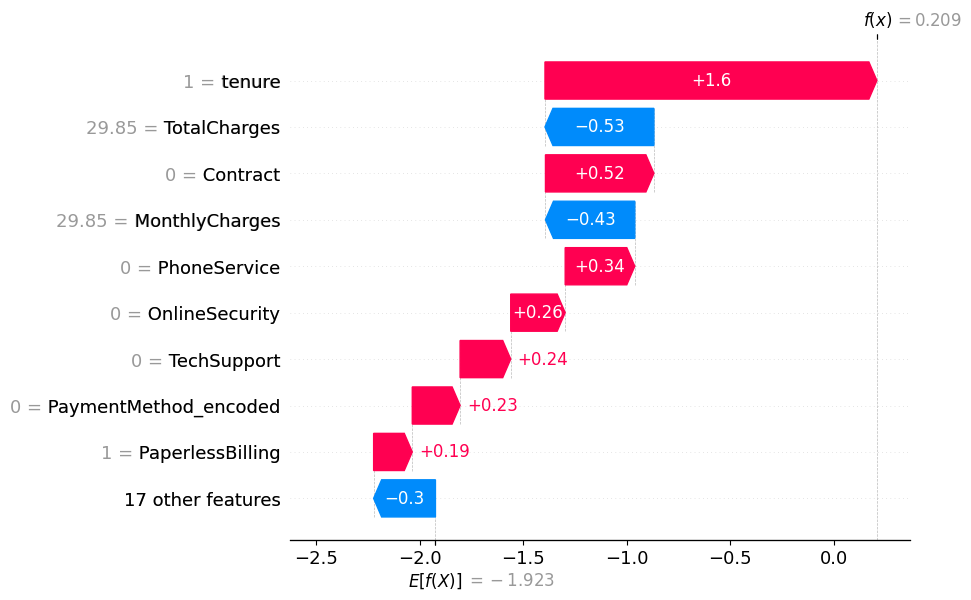

In [30]:
import shap

explainer = shap.Explainer(model1, X)
shap_values = explainer(X)

shap.plots.waterfall(shap_values[0])

---

<h2><center> Completing your test </center></h2>

- Once you have completed your test and answered all the questions:
  
- You can open the guide using the button located on the far right of your screen.

- The button will look like this image:  
  ![](additional_files/End_guide_button.png)

- Clicking on this button will allow you to mark the test as complete using the button shown below:  
  ![](additional_files/completion_button.png)

- Please click on **Mark as Completed** to end and submit your test.

- Thank you!
